In [1]:
import yaml
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, HDBSCAN
from sklearn.metrics import silhouette_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_score
from scipy.stats import ttest_ind
from xgboost import XGBClassifier
from MLstatkit.stats import Delong_test
from MLstatkit import Delong_test

from scipy.stats import chi2_contingency
# Brand palette, reused across every chart in this notebook
CARD   = "#2B2B2B"
BORDER = "#988E6E"
TEXT   = "#6D1F3A"
ACCENT = "#C4B89A"
DIM    = "dimgray"

C:\Users\clair\AppData\Local\Temp\ipykernel_15324\348755805.py:24: UserWarning: Importing from MLstatkit.stats is deprecated and will be removed in v0.2.0. Please use `from MLstatkit import ...` instead.
  from MLstatkit.stats import Delong_test


In [2]:
with open("../config.yaml", 'r') as file:
    config = yaml.safe_load(file)

# Modeling-ready data: numeric, scaled-where-needed, job/marital already one-hot encoded
data = pd.read_csv(config['data']['clean']['file5'], quotechar='"', sep=";")

In [3]:
 data.columns

Index(['age', 'default', 'housing', 'loan', 'campaign', 'pdays', 'previous',
       'income', 'converted', 'balance_log', 'balance_negative',
       'job_blue-collar', 'job_entrepreneur', 'job_housemaid',
       'job_management', 'job_retired', 'job_self-employed', 'job_services',
       'job_student', 'job_technician', 'job_unemployed', 'job_unknown',
       'marital_married', 'marital_single', 'education_0', 'education_1',
       'education_2', 'contact_telephone', 'contact_unknown', 'poutcome_other',
       'poutcome_success', 'poutcome_unknown', 'month_aug', 'month_dec',
       'month_feb', 'month_jan', 'month_jul', 'month_jun', 'month_mar',
       'month_may', 'month_nov', 'month_oct', 'month_sep'],
      dtype='str')

In [4]:
demo_features = ['age','job','income','marital','education', 'default','housing','loan', 'balance_negative','balance_log','converted']

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    data.drop(columns=['converted']), data.converted, test_size=0.20, random_state=0
)
X_train.shape, X_test.shape

((36168, 42), (9043, 42))

In [6]:
std_scaler = StandardScaler()
std_scaler.fit(X_train)

X_train_df = pd.DataFrame(
    std_scaler.transform(X_train), columns=X_train.columns, index=X_train.index
)
X_test_df = pd.DataFrame(
    std_scaler.transform(X_test), columns=X_test.columns, index=X_test.index
)

In [7]:
forest = RandomForestClassifier(n_estimators=100, max_depth=20, class_weight="balanced", random_state=42)
forest.fit(X_train_df, y_train)

y_pred_baseline = forest.predict(X_test_df)
print(f"Accuracy: {forest.score(X_test_df, y_test):.2f}")
print(classification_report(y_test, y_pred_baseline))

Accuracy: 0.85
              precision    recall  f1-score   support

           0       0.93      0.90      0.91      7980
           1       0.39      0.47      0.43      1063

    accuracy                           0.85      9043
   macro avg       0.66      0.69      0.67      9043
weighted avg       0.86      0.85      0.86      9043



In [8]:
pd.Series(forest.feature_importances_, index=X_train_df.columns).sort_values(ascending=False)

balance_log          0.157320
age                  0.139981
campaign             0.071783
poutcome_success     0.068958
contact_unknown      0.065929
pdays                0.058223
housing              0.041261
income               0.036987
previous             0.029918
loan                 0.019398
month_may            0.018403
marital_married      0.018144
poutcome_unknown     0.016442
month_mar            0.015427
education_1          0.015033
marital_single       0.014787
month_jun            0.014511
month_oct            0.014315
month_aug            0.013890
education_2          0.013842
month_nov            0.012849
month_jul            0.012564
education_0          0.011752
job_blue-collar      0.011408
contact_telephone    0.011060
job_technician       0.008965
month_sep            0.008672
balance_negative     0.007844
job_management       0.007637
month_jan            0.007404
job_services         0.007222
month_feb            0.007154
job_self-employed    0.005552
job_entrep

In [9]:
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [5, 8, 12],
    'min_samples_leaf': [2, 4, 6],
    'class_weight': ['balanced', 'balanced_subsample'],
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid_rf, cv=5, scoring='roc_auc', n_jobs=-1
)
grid_search.fit(X_train_df, y_train)

print(f"Optimized Model ROC-AUC: {grid_search.best_score_:.4f}")
print(f"Best Parameters: {grid_search.best_params_}")

Optimized Model ROC-AUC: 0.7853
Best Parameters: {'class_weight': 'balanced', 'max_depth': 12, 'min_samples_leaf': 6, 'n_estimators': 200}


In [10]:
final_rf = RandomForestClassifier(**grid_search.best_params_, random_state=42)
final_rf.fit(X_train_df, y_train)

probs_rf = final_rf.predict_proba(X_test_df)[:, 1]
y_pred_rf = final_rf.predict(X_test_df)

print("=== Final Optimized Global Random Forest ===")
print(f"ROC-AUC: {roc_auc_score(y_test, probs_rf):.4f}")
print(classification_report(y_test, y_pred_rf))

=== Final Optimized Global Random Forest ===
ROC-AUC: 0.7798
              precision    recall  f1-score   support

           0       0.94      0.84      0.89      7980
           1       0.33      0.61      0.43      1063

    accuracy                           0.81      9043
   macro avg       0.64      0.72      0.66      9043
weighted avg       0.87      0.81      0.83      9043



In [11]:
pd.Series(final_rf.feature_importances_, index=X_train_df.columns).sort_values(ascending=False)

poutcome_success     0.137194
contact_unknown      0.127226
age                  0.083834
pdays                0.081934
housing              0.074884
balance_log          0.073205
campaign             0.039571
previous             0.038250
poutcome_unknown     0.034777
month_may            0.032766
income               0.028706
month_mar            0.027078
month_oct            0.022248
marital_married      0.019191
loan                 0.016793
month_aug            0.016104
month_jun            0.015673
marital_single       0.014237
month_jul            0.012795
month_nov            0.012778
month_sep            0.011352
job_blue-collar      0.009415
education_2          0.008024
month_jan            0.006131
education_0          0.005903
balance_negative     0.005677
education_1          0.005356
job_student          0.004433
contact_telephone    0.004419
job_retired          0.004274
month_feb            0.003516
job_technician       0.003457
job_management       0.003363
poutcome_o

In [12]:
log_reg = LogisticRegression(max_iter=1000, class_weight='balanced')
log_reg.fit(X_train_df, y_train)

y_pred = log_reg.predict(X_test_df)
probs = log_reg.predict_proba(X_test_df)[:, 1]

print(f"Accuracy: {log_reg.score(X_test_df, y_test):.2f}")
print(f"ROC-AUC: {roc_auc_score(y_test, probs):.4f}")
print(classification_report(y_test, y_pred))

Accuracy: 0.76
ROC-AUC: 0.7659
              precision    recall  f1-score   support

           0       0.94      0.77      0.85      7980
           1       0.27      0.63      0.38      1063

    accuracy                           0.76      9043
   macro avg       0.61      0.70      0.61      9043
weighted avg       0.86      0.76      0.79      9043



In [13]:
param_grid_lr = {
    'penalty': ['l1', 'l2', 'elasticnet'],
    'solver': ['saga'],
    'C': [0.1, 1, 10],
    'l1_ratio': [0.5],
    'max_iter': [1000],
    'class_weight': ['balanced'],
}

grid_search_lr = GridSearchCV(LogisticRegression(max_iter=10000), param_grid_lr, cv=5, scoring='roc_auc')
grid_search_lr.fit(X_train_df, y_train)

print("Best parameters:", grid_search_lr.best_params_)

C:\Users\clair\documents\ironhack\final_project\Final-Project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\clair\documents\ironhack\final_project\Final-Project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
C:\Users\clair\documents\ironhack\final_project\Final-Project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, 

Best parameters: {'C': np.float64(0.021544346900318832), 'class_weight': 'balanced', 'l1_ratio': 0.5, 'max_iter': 1000, 'penalty': 'l1', 'solver': 'saga'}


In [14]:
log_reg = LogisticRegression(**grid_search_lr.best_params_, random_state=42)
log_reg.fit(X_train_df, y_train)

y_pred = log_reg.predict(X_test_df)
probs_lr = log_reg.predict_proba(X_test_df)[:, 1]

print(f"Accuracy: {log_reg.score(X_test_df, y_test):.2f}")
print(f"ROC-AUC: {roc_auc_score(y_test, probs):.4f}")
print(classification_report(y_test, y_pred))

C:\Users\clair\documents\ironhack\final_project\Final-Project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\clair\documents\ironhack\final_project\Final-Project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1421: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
C:\Users\clair\documents\ironhack\final_project\Final-Project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.5. penalty is deprecated. Please use l1_ratio only.
  warnings.wa

Accuracy: 0.76
ROC-AUC: 0.7659
              precision    recall  f1-score   support

           0       0.94      0.78      0.85      7980
           1       0.27      0.63      0.38      1063

    accuracy                           0.76      9043
   macro avg       0.61      0.70      0.62      9043
weighted avg       0.86      0.76      0.80      9043



In [15]:
param_grid_xgb = {
    'max_depth': [3, 5, 7],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'learning_rate': [0.01, 0.1, 0.3],
}

xgb_base = XGBClassifier(n_estimators=100, objective='binary:logistic', random_state=42)
grid_search_xgb = GridSearchCV(estimator=xgb_base, param_grid=param_grid_xgb, cv=3, n_jobs=-1, verbose=1)
grid_search_xgb.fit(X_train_df, y_train)

print("Best parameters:", grid_search_xgb.best_params_)
print(f"Best CV score: {grid_search_xgb.best_score_:.4f}")

Fitting 3 folds for each of 243 candidates, totalling 729 fits
Best parameters: {'colsample_bytree': 0.6, 'learning_rate': 0.1, 'max_depth': 3, 'min_child_weight': 1, 'subsample': 0.8}
Best CV score: 0.8943


In [16]:
xgb_clf = XGBClassifier(**grid_search_xgb.best_params_, n_estimators=100, random_state=42)
xgb_clf.fit(X_train_df, y_train)

y_pred_xgb = xgb_clf.predict(X_test_df)
probs_xgb = xgb_clf.predict_proba(X_test_df)[:, 1]

print(f"Accuracy: {xgb_clf.score(X_test_df, y_test):.2f}")
print(f"ROC-AUC: {roc_auc_score(y_test, probs_xgb):.4f}")
print(classification_report(y_test, y_pred_xgb))

Accuracy: 0.89
ROC-AUC: 0.7838
              precision    recall  f1-score   support

           0       0.90      0.98      0.94      7980
           1       0.63      0.19      0.30      1063

    accuracy                           0.89      9043
   macro avg       0.77      0.59      0.62      9043
weighted avg       0.87      0.89      0.87      9043



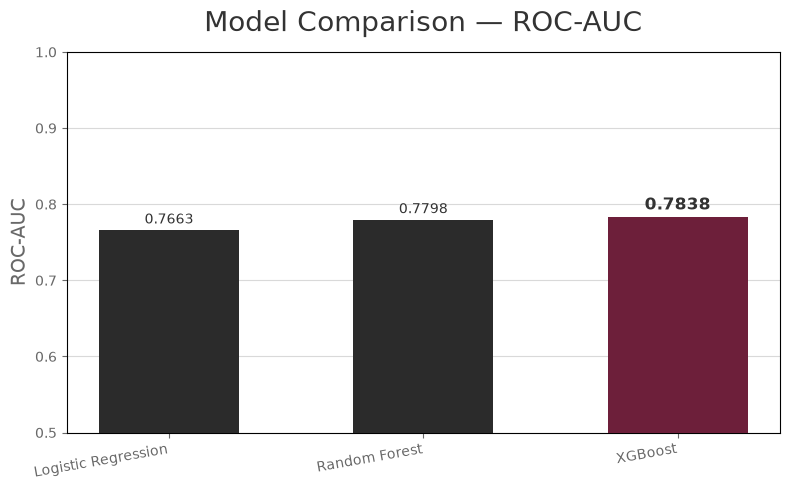

In [17]:
models = ["Logistic Regression", "Random Forest", "XGBoost"]
probs_list = [probs_lr, probs_rf, probs_xgb]
auc_scores_final = [roc_auc_score(y_test, p) for p in probs_list]

best_idx = auc_scores_final.index(max(auc_scores_final))
colors = [CARD] * len(models)
colors[best_idx] = TEXT

fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_alpha(0)
ax.set_facecolor("none")

bars = ax.bar(models, auc_scores_final, color=colors, width=0.55, zorder=3)

for i, (bar, score) in enumerate(zip(bars, auc_scores_final)):
    ax.text(bar.get_x() + bar.get_width() / 2, score + 0.004, f"{score:.4f}",
            ha="center", va="bottom", fontsize=12 if i == best_idx else 10,
            color="0.2", fontweight="bold" if i == best_idx else "normal")

ax.set_ylim(0.5, 1.0)
ax.set_ylabel("ROC-AUC", fontsize=14, color=DIM)
ax.set_title("Model Comparison — ROC-AUC", fontsize=20, color="0.2", pad=15)
ax.tick_params(colors=DIM)
ax.yaxis.grid(True, alpha=0.25, color=DIM)
ax.set_axisbelow(True)
plt.xticks(rotation=10, ha="right", color=DIM)
plt.tight_layout()
plt.savefig('../figures/model-comparison.png', transparent=True, dpi=300)
plt.show()

In [18]:
z, p, ci_A, ci_B, auc_A, auc_B, info = Delong_test(
    y_test, probs_rf, probs_lr, alpha=0.95, return_ci=True, return_auc=True, verbose=1
)
print(f"Random Forest AUC: {auc_A:.4f}, CI = {ci_A}")
print(f"Logistic Regression AUC: {auc_B:.4f}, CI = {ci_B}")
print(f"z = {z:.4f}, p = {p:.3e}")

=== DeLong Test ===
Samples: total=9043, pos=1063, neg=7980
Tie rate: A=0.003, B=0.001
Step 1) Attempt standard DeLong.
[delong] z = -3.479836, p = 5.017e-04
Random Forest AUC: 0.7798, CI = (0.7632957570449166, 0.7963907357628319)
Logistic Regression AUC: 0.7663, CI = (0.7495268003727438, 0.7829796774870044)
z = -3.4798, p = 5.017e-04


In [19]:
z, p, ci_A, ci_B, auc_A, auc_B, info = Delong_test(
    y_test, probs_rf, probs_xgb, alpha=0.95, return_ci=True, return_auc=True, verbose=1
)
print(f"Random Forest AUC: {auc_A:.4f}, CI = {ci_A}")
print(f"XGBoost AUC: {auc_B:.4f}, CI = {ci_B}")
print(f"z = {z:.4f}, p = {p:.3e}")

=== DeLong Test ===
Samples: total=9043, pos=1063, neg=7980
Tie rate: A=0.003, B=0.114
Step 1) Attempt standard DeLong.
[delong] z = 1.814730, p = 6.957e-02
Random Forest AUC: 0.7798, CI = (0.7632957570449166, 0.7963907357628319)
XGBoost AUC: 0.7838, CI = (0.7674345336678724, 0.8001722773389485)
z = 1.8147, p = 6.957e-02


In [20]:
z, p, ci_A, ci_B, auc_A, auc_B, info = Delong_test(
    y_test, probs_lr, probs_xgb, alpha=0.95, return_ci=True, return_auc=True, verbose=1
)
print(f"Logistic Regression AUC: {auc_A:.4f}, CI = {ci_A}")
print(f"XGBoost AUC: {auc_B:.4f}, CI = {ci_B}")
print(f"z = {z:.4f}, p = {p:.3e}")

=== DeLong Test ===
Samples: total=9043, pos=1063, neg=7980
Tie rate: A=0.001, B=0.114
Step 1) Attempt standard DeLong.
[delong] z = 5.320579, p = 1.034e-07
Logistic Regression AUC: 0.7663, CI = (0.7495268003727438, 0.7829796774870044)
XGBoost AUC: 0.7838, CI = (0.7674345336678724, 0.8001722773389485)
z = 5.3206, p = 1.034e-07
